# Imports and Setup

Bagian ini memuat:
- Import library utama
- Konfigurasi untuk **PERSONALIZED forecasting** (1 model per user)
- Utility untuk evaluasi, tuning threshold, dan ringkasan per-user

- Semua nama kolom kini snake_case (mis. `user_id`, `stress_level`, `created_at`, `study_hour_per_day`).
- Kolom `is_restored` adalah metadata input/restore dan **tidak** dipakai sebagai fitur model.


In [22]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.simplefilter("ignore")

import json
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import requests
from sqlalchemy import create_engine, text

from sklearn.metrics._classification import accuracy_score, f1_score
from sklearn.model_selection import ParameterGrid

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from dotenv import load_dotenv
from pathlib import Path
load_dotenv(Path.cwd().joinpath("../../.env").resolve(), override=True)

# =============================================================================
# 0) CONFIG
# =============================================================================

# Manual Train / Train Manual
PARAMETERS = {
    "data_source": "csv",
    "dataset_path": "../datasets/stress_forecast.csv",
    "user_id": 0,
    "window_size": 60,
    "enable_eda": True,
    # optional override:
    # "output_path": "...",
    # "secondary_output_path": "...",
}
DEFAULT_PARAMETERS = PARAMETERS
PARAMETERS = globals().get("PARAMETERS") or DEFAULT_PARAMETERS

# Default Train
# PARAMETERS = globals().get("PARAMETERS")

ENABLE_EDA = PARAMETERS.get("enable_eda", False)
data_source = PARAMETERS.get("data_source", os.getenv("DATA_SOURCE", "db"))
user_id = PARAMETERS.get("user_id")
window_size = int(PARAMETERS.get("window_size", 60) or 60)

# primary output (existing)
output_path = PARAMETERS.get("output_path")

# secondary output (dinamis: PARAMETERS > env)
secondary_output_path = PARAMETERS.get(
    "secondary_output_path",
    os.getenv("SECONDARY_OUTPUT_PATH")
)

metrics_output_path = PARAMETERS.get("metrics_output_path")
dataset_path = PARAMETERS.get("dataset_path")
streak_start_date = PARAMETERS.get("streak_start_date")

if window_size != 60:
    print("window_size override diabaikan. Sistem menggunakan fixed 60.")
    window_size = 60

def _resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / "nostressia-backend" / "app" / "models_ml").exists():
            return parent
    return cwd

repo_root = _resolve_repo_root()

# primary default (existing)
default_model_out = repo_root / "nostressia-backend" / "app" / "models_ml" / "personalized_forecast.joblib"
MODEL_OUT = Path(output_path) if output_path else default_model_out

# secondary default (ngikutin cara: repo_root + relative path)
default_secondary_model_out = (
    repo_root
    / "nostressia-machine-learning"
    / "Stress-Forecast"
    / "models"
    / "personalized_forecast.joblib"
)

SECOND_MODEL_OUT = (
    Path(secondary_output_path)
    if secondary_output_path
    else default_secondary_model_out
)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DBbaseline_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

BACKEND_BASE_URL = os.getenv("BACKEND_BASE_URL")
INTERNAL_TOKEN = os.getenv("INTERNAL_TOKEN")

DATE_COL   = "date"
USER_COL   = "user_id"
TARGET_COL = "stress_level"  # 0..2

WINDOW   = 3
TEST_LEN = 12

VAL_WINDOWS = [(10, 20), (15, 25)]
THRESHOLDS  = np.linspace(0.05, 0.95, 19)

RANDOM_STATE = 26

# Personalized: default = False (no semi-global/global)
USE_USER_ID_FEATURE = False

# Threshold tuning:
# - True  => tune threshold per user (fair: uses only that user's CV folds)
# - False => tune one global threshold pooled across users
TUNE_THRESHOLD_PER_USER = True

# Print per-user details for baselines and selected best model
PRINT_PER_USER_DETAILS = True


# =============================================================================
# Print helpers
# =============================================================================
def kv(k, v):
    print(f"{k:<20}: {v}")

def safe_class_counts(y):
    y = np.asarray(y).astype(int)
    return {0: int((y == 0).sum()), 1: int((y == 1).sum())}

def print_per_user_breakdown(title, per_user_records, thr_info=None):
    print(f"\n{title}")
    for r in per_user_records:
        uid = r["uid"]
        y = np.asarray(r["y"]).astype(int)
        pred = np.asarray(r["pred"]).astype(int)
        acc = float(accuracy_score(y, pred))
        f1  = float(f1_score(y, pred, zero_division=0))
        dist = safe_class_counts(y)

        extra = ""
        if thr_info is not None:
            if isinstance(thr_info, dict) and uid in thr_info:
                extra = f" | thr={float(thr_info[uid]):.2f}"
            elif isinstance(thr_info, (float, int)):
                extra = f" | thr={float(thr_info):.2f}"

        print(f"uid={uid} | n={len(y):<3} | dist={dist} | acc={acc:.4f} | f1={f1:.4f}{extra}")


# =============================================================================
# Core helpers
# =============================================================================
def eval_bin(y_true, y_pred):
    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1":  float(f1_score(y_true, y_pred, zero_division=0)),
    }

def tune_thr_from_proba(y_true, p_high, thresholds=THRESHOLDS):
    best_thr, best_f1 = None, -1.0
    for thr in thresholds:
        pred = (p_high >= thr).astype(int)
        f1 = float(f1_score(y_true, pred, zero_division=0))
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return float(best_thr), float(best_f1)

def per_user_macro_metrics(per_user_records):
    accs, f1s = [], []
    for r in per_user_records:
        accs.append(accuracy_score(r["y"], r["pred"]))
        f1s.append(f1_score(r["y"], r["pred"], zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))

def cv_folds_user(tp_df):
    folds = []
    for (v0, v1) in VAL_WINDOWS:
        if len(tp_df) < v1:
            continue
        tr = tp_df.iloc[:v0].copy()
        va = tp_df.iloc[v0:v1].copy()
        folds.append((tr, va))
    return folds

def min_class_count(y):
    vc = pd.Series(np.asarray(y)).value_counts()
    if len(vc) < 2:
        return 0
    return int(vc.min())


# Load and Explore Dataset

Bagian ini mencakup:
- Load dataset
- Validasi kolom wajib
- Parsing `date` dan sorting time-series per user
- Validasi range target `stress_level` (0–2)


In [23]:
# LOAD REALTIME DATA

# LOAD FROM CSV
def _load_personalized_from_csv(path, target_user_id, start_date):
    if not path:
        raise RuntimeError("dataset_path wajib untuk data_source=csv.")
    df = pd.read_csv(path)
    

    if int(target_user_id) == 0:
        # Manual Train / Train Manual
        df = df.sort_values(["user_id", "date"]).groupby("user_id").head(60)
    else:
        # Default Train
        df = df[df["user_id"] == int(target_user_id)]

    if start_date:
        df = df[pd.to_datetime(df["date"]) >= pd.to_datetime(start_date)]
    return df

if user_id is None:
    raise ValueError("user_id parameter wajib untuk training personalized.")

def _load_personalized_from_db(target_user_id, limit):
    if not all([DB_HOST, DB_USER, DB_PASSWORD, DB_NAME]):
        raise RuntimeError("DB config tidak lengkap untuk load data personalized.")
    url = (
        f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}"
        f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )
    engine = create_engine(url)
    query = """
        SELECT
            user_id,
            date,
            stress_level,
            gpa,
            extracurricular_hour_per_day,
            physical_activity_hour_per_day,
            sleep_hour_per_day,
            study_hour_per_day,
            social_hour_per_day,
            emoji,
            is_restored
        FROM stress_levels
        WHERE user_id = :user_id
        ORDER BY date DESC
        LIMIT :limit
    """
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn, params={"user_id": int(target_user_id), "limit": int(limit)})

def _load_personalized_from_api(target_user_id, limit):
    if not BACKEND_BASE_URL:
        raise RuntimeError("BACKEND_BASE_URL belum di-set untuk mode API.")
    url = f"{BACKEND_BASE_URL.rstrip('/')}/api/ml/training-data/personalized"
    headers = {}
    if INTERNAL_TOKEN:
        headers["X-Internal-Token"] = INTERNAL_TOKEN
    params = {"userId": int(target_user_id), "limit": int(limit)}
    resp = requests.get(url, headers=headers, params=params, timeout=30)
    resp.raise_for_status()
    payload = resp.json()
    return pd.DataFrame(payload.get("data", []))

if data_source == "db":
    df = _load_personalized_from_db(user_id, window_size)
elif data_source == "api":
    df = _load_personalized_from_api(user_id, window_size)
elif data_source == "csv":
    df = _load_personalized_from_csv(dataset_path, user_id, streak_start_date)
else:
    raise ValueError(f"Unknown data_source: {data_source}")

if df.empty:
    raise ValueError("SKIPPED_INSUFFICIENT_DATA: personalized dataset kosong.")

if "is_restored" not in df.columns:
    df["is_restored"] = 0
df["is_restored"] = df["is_restored"].fillna(0).astype(int)

for required_col in [DATE_COL, USER_COL, TARGET_COL]:
    if required_col not in df.columns:
        raise KeyError(f"Required column '{required_col}' not found in dataset.")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="raise")
df = df.sort_values([USER_COL, DATE_COL]).reset_index(drop=True)

if not df[TARGET_COL].dropna().between(0, 2).all():
    raise ValueError(f"'{TARGET_COL}' must be within range 0..2")

if len(df) < 14:
    raise ValueError("SKIPPED_INSUFFICIENT_DATA: data personalized kurang dari 14 baris.")

kv("DATA_SOURCE", data_source)
kv("ROWS_RAW", len(df))
kv("USERS_RAW", df[USER_COL].nunique())
kv("DATE_RANGE_RAW", f"{df[DATE_COL].min().date()} -> {df[DATE_COL].max().date()}")

print("\nHEAD:")
display(df.head())


DATA_SOURCE         : csv
ROWS_RAW            : 300
USERS_RAW           : 5
DATE_RANGE_RAW      : 2025-11-21 -> 2026-01-19

HEAD:


,stress_level_id,user_id,date,stress_level,gpa,extracurricular_hour_per_day,physical_activity_hour_per_day,sleep_hour_per_day,study_hour_per_day,social_hour_per_day,emoji,is_restored,created_at
0,1,1,2025-11-21,1,3.82,0.0,0.5,7.0,7.0,2.0,2,0,2025-11-21 23:29:33
1,2,1,2025-11-22,0,3.82,0.0,1.0,9.0,2.0,5.0,1,0,2025-11-22 20:23:04
2,3,1,2025-11-23,0,3.82,0.0,3.0,9.0,1.0,6.0,0,0,2025-11-23 20:42:45
3,4,1,2025-11-24,1,3.82,0.0,0.5,8.0,7.0,5.0,2,0,2025-11-24 23:29:32
4,5,1,2025-11-25,1,3.82,0.0,1.0,7.0,7.0,4.0,2,0,2025-11-25 23:38:40


# Exploratory Data Analysis (EDA)

Ringkasan cepat:
- Distribusi `stress_level` (0–2)
- Jumlah baris per user (indikasi kecukupan data untuk split & CV)


TARGET_DIST (0..2): {0: 140, 1: 92, 2: 68}


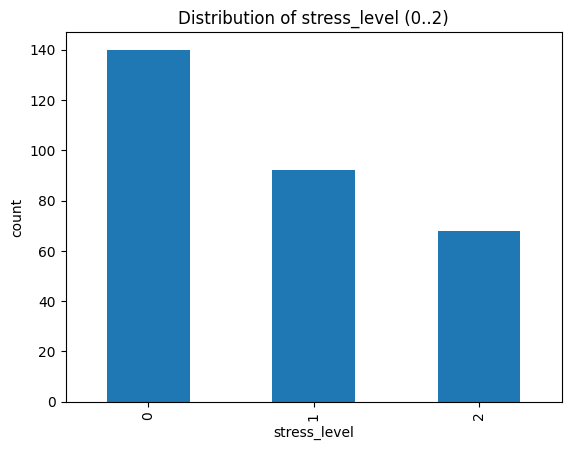


ROWS_PER_USER: {1: 60, 2: 60, 3: 60, 4: 60, 5: 60}


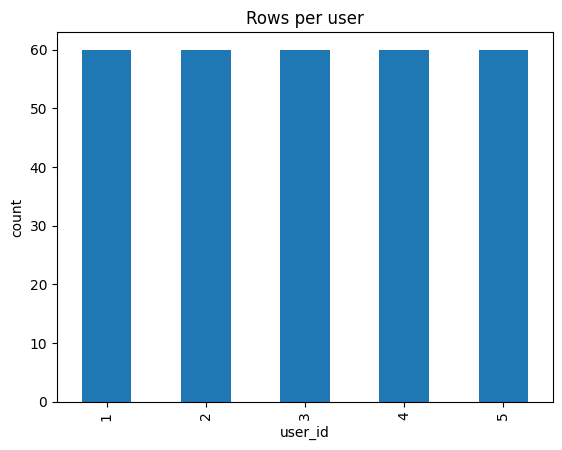

In [24]:
# EDA QUICK CHECKS
if ENABLE_EDA:
    import matplotlib.pyplot as plt

    target_counts = df[TARGET_COL].value_counts().sort_index()
    print("TARGET_DIST (0..2):", target_counts.to_dict())

    plt.figure()
    target_counts.plot(kind="bar")
    plt.title(f"Distribution of {TARGET_COL} (0..2)")
    plt.xlabel(TARGET_COL)
    plt.ylabel("count")
    plt.show()

    user_counts = df[USER_COL].value_counts()
    print("\nROWS_PER_USER:", user_counts.to_dict())

    plt.figure()
    user_counts.sort_index().plot(kind="bar")
    plt.title("Rows per user")
    plt.xlabel(USER_COL)
    plt.ylabel("count")
    plt.show()


### Added EDA Plot Pack (Forecast)
Empat plot forecast kini tersedia langsung di notebook ini (tanpa menjalankan script eksternal).

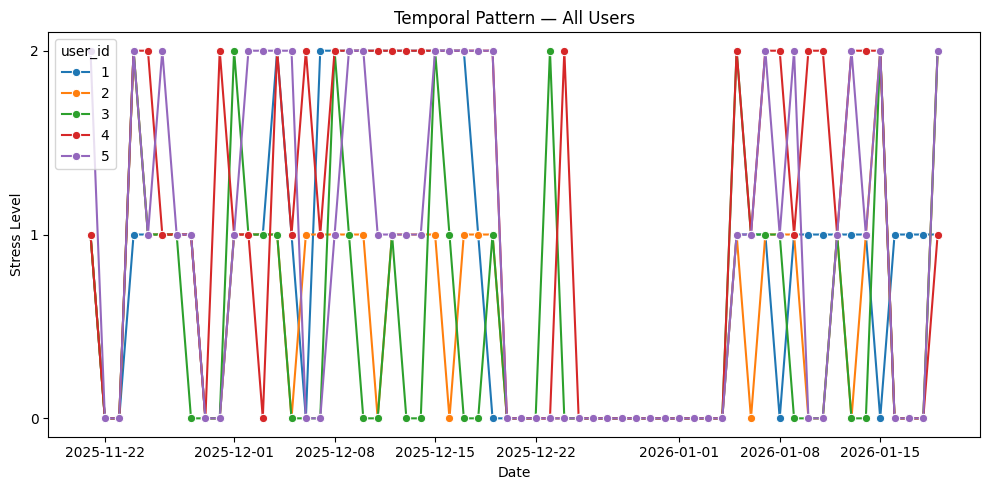

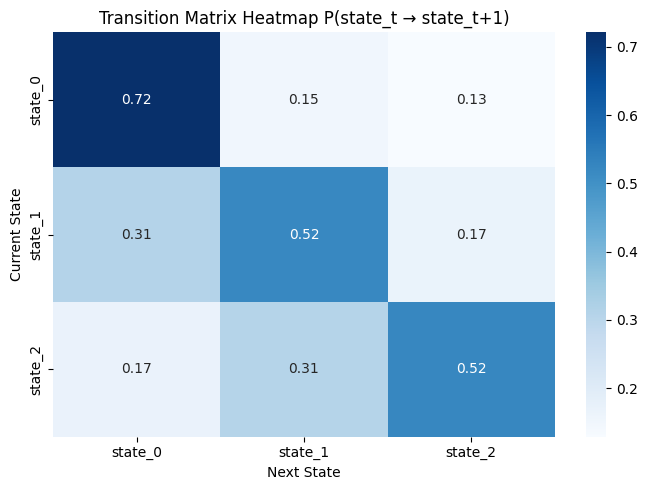

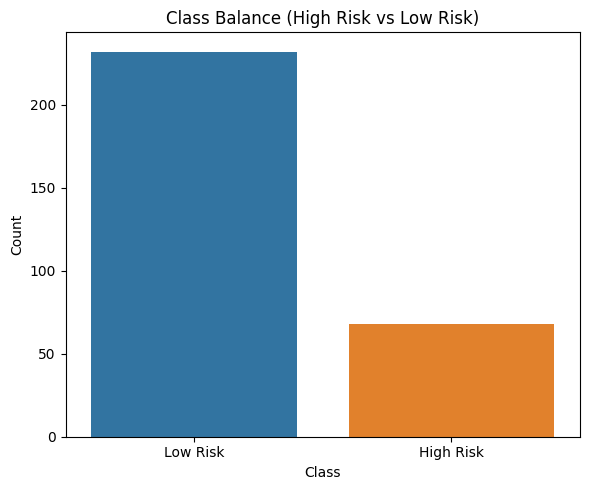

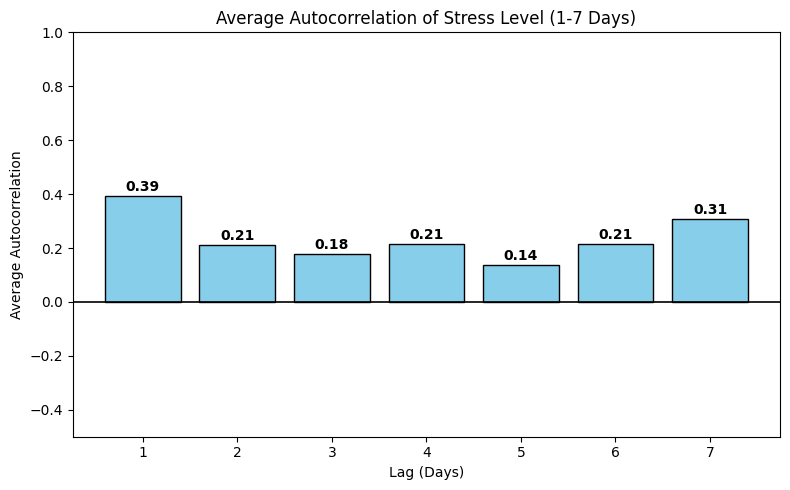

In [25]:
if ENABLE_EDA:
    # Plot Pack Forecast (4 plots)
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plot_df = df.sort_values([USER_COL, DATE_COL]).copy()

    # 1) Temporal Pattern (all users)
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=plot_df, x=DATE_COL, y=TARGET_COL, hue=USER_COL, marker="o", palette="tab10")
    plt.title("Temporal Pattern — All Users")
    plt.xlabel("Date")
    plt.ylabel("Stress Level")
    plt.yticks([0, 1, 2])
    plt.tight_layout()
    plt.show()

    # 2) Transition Matrix Heatmap P(state_t -> state_t+1)
    trans = plot_df.copy()
    trans["next_state"] = trans.groupby(USER_COL)[TARGET_COL].shift(-1)
    trans = trans.dropna(subset=["next_state"])
    matrix = pd.crosstab(trans[TARGET_COL], trans["next_state"])
    matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
    matrix.index = [f"state_{int(x)}" for x in matrix.index]
    matrix.columns = [f"state_{int(x)}" for x in matrix.columns]

    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Transition Matrix Heatmap P(state_t → state_t+1)")
    plt.xlabel("Next State")
    plt.ylabel("Current State")
    plt.tight_layout()
    plt.show()

    # 3) Class Balance (High Risk vs Low Risk)
    high = (plot_df[TARGET_COL] == 2).sum()
    low = (plot_df[TARGET_COL] != 2).sum()
    class_df = pd.DataFrame({"Class": ["Low Risk", "High Risk"], "Count": [low, high]})

    plt.figure(figsize=(6, 5))
    sns.barplot(data=class_df, x="Class", y="Count", hue="Class", legend=False)
    plt.title("Class Balance (High Risk vs Low Risk)")
    plt.tight_layout()
    plt.show()

    # 4) Autocorrelation Analysis (lag 1..7)
    lags = range(1, 8)
    acf_values = {lag: [] for lag in lags}
    for _, g in plot_df.groupby(USER_COL):
        if len(g) > max(lags):
            for lag in lags:
                corr = g[TARGET_COL].autocorr(lag=lag)
                if not np.isnan(corr):
                    acf_values[lag].append(corr)
    avg_acf = {lag: np.mean(vals) for lag, vals in acf_values.items() if vals}

    plt.figure(figsize=(8, 5))
    plt.bar(avg_acf.keys(), avg_acf.values(), color="skyblue", edgecolor="black")
    plt.title("Average Autocorrelation of Stress Level (1-7 Days)")
    plt.xlabel("Lag (Days)")
    plt.ylabel("Average Autocorrelation")
    plt.ylim(-0.5, 1)
    plt.axhline(0, color="black", linewidth=1.2)
    for lag, val in avg_acf.items():
        vpos = val + 0.02 if val >= 0 else val - 0.08
        plt.text(lag, vpos, f"{val:.2f}", ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

# Data Preprocessing

Bagian ini melakukan **feature engineering tanpa leakage**:
- Fitur kalender: `dow`, `is_weekend`
- Fitur lag target: `lag_sp_1..lag_sp_WINDOW`
- Rolling stats dari history yang berakhir di `t-1`

Transformasi label:
- `y_bin = 1` jika `stress_level >= 1`
- `y_bin = 0` jika `stress_level == 0`


In [26]:
# FEATURE ENGINEERING (NO-LEAK)
rows = []
for uid, g in df.groupby(USER_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    g["dow"] = g[DATE_COL].dt.dayofweek.astype(int)
    g["is_weekend"] = (g["dow"] >= 5).astype(int)

    for k in range(1, WINDOW + 1):
        g[f"lag_sp_{k}"] = g[TARGET_COL].shift(k)

    sp_shift = g[TARGET_COL].shift(1)

    g["sp_mean"] = sp_shift.rolling(WINDOW).mean()
    g["sp_std"]  = sp_shift.rolling(WINDOW).std().fillna(0.0)
    g["sp_min"]  = sp_shift.rolling(WINDOW).min()
    g["sp_max"]  = sp_shift.rolling(WINDOW).max()

    g["count_high"] = (sp_shift >= 1).rolling(WINDOW).sum()
    g["count_low"]  = (sp_shift == 0).rolling(WINDOW).sum()

    high = (sp_shift >= 1).astype(int).fillna(0).astype(int).tolist()
    streak, cur = [], 0
    for v in high:
        cur = cur + 1 if v == 1 else 0
        streak.append(cur)
    g["streak_high"] = streak

    diff = (sp_shift != sp_shift.shift(1)).astype(int)
    g["transitions"] = diff.rolling(WINDOW).sum()

    rows.append(g)

feat = pd.concat(rows, ignore_index=True)

# Binary labeling: y_bin = 1 if pred>=1 else 0
feat["y_bin"] = (feat[TARGET_COL] >= 1).astype(int)

feature_cols = (
    ["dow", "is_weekend"]
    + [f"lag_sp_{k}" for k in range(1, WINDOW + 1)]
    + [
        "sp_mean", "sp_std", "sp_min", "sp_max",
        "count_high", "count_low",
        "streak_high", "transitions",
    ]
)
if USE_USER_ID_FEATURE:
    feature_cols = [USER_COL] + feature_cols

feat = feat.dropna(subset=feature_cols + ["y_bin"]).reset_index(drop=True)
users = sorted(feat[USER_COL].unique().tolist())

kv("ROWS_FEAT", len(feat))
kv("USERS", users)
kv("DATE_RANGE_FEAT", f"{feat[DATE_COL].min().date()} -> {feat[DATE_COL].max().date()}")
kv("WINDOW", WINDOW)
kv("TEST_LEN", TEST_LEN)
kv("FEATURES_COUNT", len(feature_cols))
kv("USE_USER_ID_FEATURE", USE_USER_ID_FEATURE)
kv("BINARY_DIST", feat["y_bin"].value_counts().to_dict())
kv("VAL_WINDOWS", VAL_WINDOWS)
kv("TUNE_THRESHOLD_PER_USER", TUNE_THRESHOLD_PER_USER)

display(feat[[USER_COL, DATE_COL, TARGET_COL, "y_bin"] + feature_cols].head())


ROWS_FEAT           : 285
USERS               : [1, 2, 3, 4, 5]
DATE_RANGE_FEAT     : 2025-11-24 -> 2026-01-19
WINDOW              : 3
TEST_LEN            : 12
FEATURES_COUNT      : 13
USE_USER_ID_FEATURE : False
BINARY_DIST         : {1: 155, 0: 130}
VAL_WINDOWS         : [(10, 20), (15, 25)]
TUNE_THRESHOLD_PER_USER: True


,user_id,date,stress_level,y_bin,dow,is_weekend,lag_sp_1,lag_sp_2,lag_sp_3,sp_mean,sp_std,sp_min,sp_max,count_high,count_low,streak_high,transitions
0,1,2025-11-24,1,1,0,0,0.0,0.0,1.0,0.333333,0.57735,0.0,1.0,1.0,2.0,0,2.0
1,1,2025-11-25,1,1,1,0,1.0,0.0,0.0,0.333333,0.57735,0.0,1.0,1.0,2.0,1,2.0
2,1,2025-11-26,1,1,2,0,1.0,1.0,0.0,0.666667,0.57735,0.0,1.0,2.0,1.0,2,1.0
3,1,2025-11-27,1,1,3,0,1.0,1.0,1.0,1.000000,0.00000,1.0,1.0,3.0,0.0,3,1.0
4,1,2025-11-28,1,1,4,0,1.0,1.0,1.0,1.000000,0.00000,1.0,1.0,3.0,0.0,4,0.0


# Model Training and Evaluation

Cakupan bagian ini:
- Split time-based per user (TEST = last `TEST_LEN`)
- Baseline L1: Persistence
- Baseline L2: Markov per-user + threshold tuning (pooled CV)
- Kandidat model ML per user (tanpa user_id sebagai fitur)
- SVM calibrated dengan cv adaptif (SAFE)
- Leaderboard + seleksi model terbaik vs baseline
- Simpan artifact ke file `.joblib`


In [27]:
# SPLIT PER USER (TIME-BASED)
per_user = {}
split_rows = []

for uid in users:
    g = feat[feat[USER_COL] == uid].sort_values(DATE_COL).reset_index(drop=True)
    n = len(g)
    test_start = n - TEST_LEN
    if test_start <= 10:
        raise ValueError(f"User {uid}: insufficient rows for split (n={n}, TEST_LEN={TEST_LEN}).")

    tp = g.iloc[:test_start].copy()
    te = g.iloc[test_start:].copy()

    per_user[uid] = {"train_pool": tp, "test": te}

    split_rows.append({
        "uid": uid,
        "n_total": n,
        "n_train_pool": len(tp),
        "n_test": len(te),
        "train_pool_dist": safe_class_counts(tp["y_bin"].values),
        "test_dist": safe_class_counts(te["y_bin"].values),
    })

kv("TOTAL_TRAINPOOL", sum(r["n_train_pool"] for r in split_rows))
kv("TOTAL_TEST", sum(r["n_test"] for r in split_rows))

print("\nPER_USER_SPLIT:")
for r in split_rows:
    print(
        f"uid={r['uid']} | total={r['n_total']} | train_pool={r['n_train_pool']} dist={r['train_pool_dist']} "
        f"| test={r['n_test']} dist={r['test_dist']}"
    )


TOTAL_TRAINPOOL     : 225
TOTAL_TEST          : 60

PER_USER_SPLIT:
uid=1 | total=57 | train_pool=45 dist={0: 20, 1: 25} | test=12 dist={0: 2, 1: 10}
uid=2 | total=57 | train_pool=45 dist={0: 22, 1: 23} | test=12 dist={0: 6, 1: 6}
uid=3 | total=57 | train_pool=45 dist={0: 27, 1: 18} | test=12 dist={0: 8, 1: 4}
uid=4 | total=57 | train_pool=45 dist={0: 17, 1: 28} | test=12 dist={0: 3, 1: 9}
uid=5 | total=57 | train_pool=45 dist={0: 20, 1: 25} | test=12 dist={0: 5, 1: 7}


In [28]:
# BASELINE L1: PERSISTENCE (PER USER)
persist_user_records = []
all_true, all_pred = [], []

for uid in users:
    te = per_user[uid]["test"]
    y = te["y_bin"].astype(int).values
    pred = (te["lag_sp_1"] >= 1).astype(int).values

    persist_user_records.append({"uid": uid, "y": y, "pred": pred})
    all_true.append(y)
    all_pred.append(pred)

y_all = np.concatenate(all_true)
pred_all = np.concatenate(all_pred)

persist_pooled = eval_bin(y_all, pred_all)
persist_macro_acc, persist_macro_f1 = per_user_macro_metrics(persist_user_records)

kv("TEST_POOLED_ACC", persist_pooled["acc"])
kv("TEST_POOLED_F1", persist_pooled["f1"])
kv("TEST_MACRO_ACC", persist_macro_acc)
kv("TEST_MACRO_F1", persist_macro_f1)

if PRINT_PER_USER_DETAILS:
    print_per_user_breakdown("PER-USER (Persistence) on TEST:", persist_user_records)


TEST_POOLED_ACC     : 0.6333333333333333
TEST_POOLED_F1      : 0.6944444444444444
TEST_MACRO_ACC      : 0.6333333333333333
TEST_MACRO_F1       : 0.6306349206349207

PER-USER (Persistence) on TEST:
uid=1 | n=12  | dist={0: 2, 1: 10} | acc=0.6667 | f1=0.8000
uid=2 | n=12  | dist={0: 6, 1: 6} | acc=0.5000 | f1=0.5000
uid=3 | n=12  | dist={0: 8, 1: 4} | acc=0.5000 | f1=0.2500
uid=4 | n=12  | dist={0: 3, 1: 9} | acc=0.8333 | f1=0.8889
uid=5 | n=12  | dist={0: 5, 1: 7} | acc=0.6667 | f1=0.7143


In [29]:
# BASELINE L2: MARKOV PER USER (prev_high, dow) + THRESHOLD TUNING
def train_markov_one_user(df_train):
    counts = np.zeros((2, 7, 2), dtype=int)  # prev(2) x dow(7) x y(2)
    prev = (df_train["lag_sp_1"] >= 1).astype(int).values
    dow  = (df_train["dow"]).astype(int).values
    yb   = (df_train["y_bin"]).astype(int).values
    for p, d, y in zip(prev, dow, yb):
        counts[p, d, y] += 1
    probs = (counts + 1) / (counts.sum(axis=2, keepdims=True) + 2)  # Laplace smoothing
    return probs

def markov_proba_user(probs, df_eval):
    prev = (df_eval["lag_sp_1"] >= 1).astype(int).values
    dow  = (df_eval["dow"]).astype(int).values
    return np.array([probs[p, d, 1] for p, d in zip(prev, dow)], dtype=float)

# Pooled CV threshold tuning (fair: uses only train_pool folds)
cv_true, cv_phigh = [], []
cv_fold_stats = []

for uid in users:
    tp = per_user[uid]["train_pool"]
    folds = cv_folds_user(tp)
    for (tr_df, va_df) in folds:
        probs = train_markov_one_user(tr_df)
        p = markov_proba_user(probs, va_df)
        cv_true.append(va_df["y_bin"].astype(int).values)
        cv_phigh.append(p)
        cv_fold_stats.append({"uid": uid, "tr_len": len(tr_df), "va_len": len(va_df)})

if len(cv_true) == 0:
    raise ValueError("No valid CV folds. Reduce VAL_WINDOWS / TEST_LEN / WINDOW.")

cv_true = np.concatenate(cv_true)
cv_phigh = np.concatenate(cv_phigh)

thr_mk, cv_f1_mk = tune_thr_from_proba(cv_true, cv_phigh)

mk_models = {}
markov_user_records = []
all_true, all_pred = [], []

for uid in users:
    tp = per_user[uid]["train_pool"]
    te = per_user[uid]["test"]

    probs = train_markov_one_user(tp)
    mk_models[uid] = probs

    p = markov_proba_user(probs, te)
    pred = (p >= thr_mk).astype(int)
    y = te["y_bin"].astype(int).values

    markov_user_records.append({"uid": uid, "y": y, "pred": pred})
    all_true.append(y)
    all_pred.append(pred)

y_all = np.concatenate(all_true)
pred_all = np.concatenate(all_pred)

markov_pooled = eval_bin(y_all, pred_all)
markov_macro_acc, markov_macro_f1 = per_user_macro_metrics(markov_user_records)

kv("CV_FOLDS_TOTAL", len(cv_fold_stats))
kv("CV_POOLED_DIST", safe_class_counts(cv_true))
kv("BEST_THR_MARKOV", thr_mk)
kv("CV_POOLED_F1", cv_f1_mk)
kv("TEST_POOLED_ACC", markov_pooled["acc"])
kv("TEST_POOLED_F1", markov_pooled["f1"])
kv("TEST_MACRO_ACC", markov_macro_acc)
kv("TEST_MACRO_F1", markov_macro_f1)

if PRINT_PER_USER_DETAILS:
    print_per_user_breakdown("PER-USER (Markov) on TEST:", markov_user_records, thr_info=thr_mk)


CV_FOLDS_TOTAL      : 10
CV_POOLED_DIST      : {0: 19, 1: 81}
BEST_THR_MARKOV     : 0.05
CV_POOLED_F1        : 0.8950276243093923
TEST_POOLED_ACC     : 0.6
TEST_POOLED_F1      : 0.75
TEST_MACRO_ACC      : 0.6000000000000001
TEST_MACRO_F1       : 0.7339485076327181

PER-USER (Markov) on TEST:
uid=1 | n=12  | dist={0: 2, 1: 10} | acc=0.8333 | f1=0.9091 | thr=0.05
uid=2 | n=12  | dist={0: 6, 1: 6} | acc=0.5000 | f1=0.6667 | thr=0.05
uid=3 | n=12  | dist={0: 8, 1: 4} | acc=0.3333 | f1=0.5000 | thr=0.05
uid=4 | n=12  | dist={0: 3, 1: 9} | acc=0.7500 | f1=0.8571 | thr=0.05
uid=5 | n=12  | dist={0: 5, 1: 7} | acc=0.5833 | f1=0.7368 | thr=0.05


In [30]:
# PREPROCESS (FOR ML)
cat_cols = ["dow", "is_weekend"]
if USE_USER_ID_FEATURE:
    cat_cols = [USER_COL] + cat_cols

num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
    ],
    remainder="drop",
)

kv("CAT_COLS", cat_cols)
kv("NUM_COLS_COUNT", len(num_cols))


CAT_COLS            : ['dow', 'is_weekend']
NUM_COLS_COUNT      : 11


In [31]:
# CANDIDATE MODELS (NON-SVM) + SVM SAFE CONFIG
try:
    bag_base = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    BAG_ESTIMATOR_PARAM = "clf__estimator__"
except TypeError:
    bag_base = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    BAG_ESTIMATOR_PARAM = "clf__base_estimator__"

CANDIDATES = {
    "LogReg": (
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0], "clf__solver": ["liblinear"]}
    ),
    "DecisionTree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4, 8]}
    ),
    "RandomForest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        {"clf__n_estimators": [200, 400, 800], "clf__max_depth": [None, 6, 10],
         "clf__min_samples_leaf": [1, 2, 4], "clf__max_features": ["sqrt"]}
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        {"clf__n_estimators": [200, 400, 800], "clf__max_depth": [None, 6, 10],
         "clf__min_samples_leaf": [1, 2, 4], "clf__max_features": ["sqrt"]}
    ),
    "HistGB": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__max_depth": [2, 3],
         "clf__max_leaf_nodes": [15, 31, 63]}
    ),
    "GradBoost": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__n_estimators": [100, 200, 400],
         "clf__max_depth": [2, 3]}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1, 0.3], "clf__n_estimators": [50, 100, 200, 400]}
    ),
    "BaggingTree": (
        bag_base,
        {"clf__n_estimators": [50, 100, 200],
         f"{BAG_ESTIMATOR_PARAM}max_depth": [2, 3, 4, None],
         f"{BAG_ESTIMATOR_PARAM}min_samples_leaf": [1, 2, 4]}
    ),
}

SVM_NAME = "LinearSVC_Calibrated_SAFE"
SVM_GRID = {"C": [0.03, 0.1, 0.3, 1.0, 3.0]}

kv("MODELS", list(CANDIDATES.keys()) + [SVM_NAME])
kv("THRESHOLDS_COUNT", len(THRESHOLDS))


MODELS              : ['LogReg', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'HistGB', 'GradBoost', 'AdaBoost', 'BaggingTree', 'LinearSVC_Calibrated_SAFE']
THRESHOLDS_COUNT    : 19


In [32]:
# TUNING UTILITIES (GLOBAL THRESHOLD OR PER-USER THRESHOLD)
def tune_global_thr_pooled_over_all_users(pipe, params):
    y_list, p_list = [], []
    for uid in users:
        tp = per_user[uid]["train_pool"]
        folds = cv_folds_user(tp)
        for tr_df, va_df in folds:
            ytr = tr_df["y_bin"].astype(int).values
            if len(np.unique(ytr)) < 2:
                continue
            pipe.set_params(**params)
            pipe.fit(tr_df[feature_cols], ytr)
            p = pipe.predict_proba(va_df[feature_cols])[:, 1]
            y_list.append(va_df["y_bin"].astype(int).values)
            p_list.append(p)

    if len(y_list) == 0:
        return None, None

    y_all = np.concatenate(y_list)
    p_all = np.concatenate(p_list)
    thr, cv_f1 = tune_thr_from_proba(y_all, p_all)
    return float(thr), float(cv_f1)

def tune_per_user_thr(pipe, params):
    thr_by_user = {}
    f1s = []

    for uid in users:
        tp = per_user[uid]["train_pool"]
        folds = cv_folds_user(tp)
        if len(folds) == 0:
            return None, None

        y_list, p_list = [], []
        for tr_df, va_df in folds:
            ytr = tr_df["y_bin"].astype(int).values
            if len(np.unique(ytr)) < 2:
                continue
            pipe.set_params(**params)
            pipe.fit(tr_df[feature_cols], ytr)
            p = pipe.predict_proba(va_df[feature_cols])[:, 1]
            y_list.append(va_df["y_bin"].astype(int).values)
            p_list.append(p)

        if len(y_list) == 0:
            return None, None

        y_u = np.concatenate(y_list)
        p_u = np.concatenate(p_list)
        thr_u, f1_u = tune_thr_from_proba(y_u, p_u)
        thr_by_user[uid] = float(thr_u)
        f1s.append(float(f1_u))

    return thr_by_user, float(np.mean(f1s))

def eval_personalized_models(models_by_user, thr_by_user_or_scalar):
    per_user_records = []
    all_true, all_pred = [], []

    for uid in users:
        te = per_user[uid]["test"]
        y = te["y_bin"].astype(int).values

        pipe = models_by_user[uid]
        p = pipe.predict_proba(te[feature_cols])[:, 1]
        thr = thr_by_user_or_scalar[uid] if isinstance(thr_by_user_or_scalar, dict) else float(thr_by_user_or_scalar)
        pred = (p >= thr).astype(int)

        per_user_records.append({"uid": uid, "y": y, "pred": pred})
        all_true.append(y)
        all_pred.append(pred)

    y_all = np.concatenate(all_true)
    pred_all = np.concatenate(all_pred)

    pooled = eval_bin(y_all, pred_all)
    macro_acc, macro_f1 = per_user_macro_metrics(per_user_records)
    macro = {"acc": float(macro_acc), "f1": float(macro_f1)}
    return pooled, macro, per_user_records


In [33]:
# PERSONALIZED ML: TRAIN + TUNE (NON-SVM)
rows = []

for name, (clf, grid) in CANDIDATES.items():
    best = None

    for params in ParameterGrid(grid):
        pipe = Pipeline([("prep", preprocess), ("clf", clf)])

        if TUNE_THRESHOLD_PER_USER:
            thr_obj, cv_score = tune_per_user_thr(pipe, params)
        else:
            thr_obj, cv_score = tune_global_thr_pooled_over_all_users(pipe, params)

        if thr_obj is None:
            continue

        if (best is None) or (cv_score > best["cv_score"]):
            best = {"params": dict(params), "thr_obj": thr_obj, "cv_score": float(cv_score)}

    if best is None:
        print(f"SKIP_MODEL: {name} (no valid params/folds)")
        continue

    # Final training per user (train_pool only)
    models_by_user = {}
    ok = True

    for uid in users:
        tp = per_user[uid]["train_pool"]
        ytr = tp["y_bin"].astype(int).values
        if len(np.unique(ytr)) < 2:
            ok = False
            break

        pipe = Pipeline([("prep", preprocess), ("clf", clf)])
        pipe.set_params(**best["params"])
        pipe.fit(tp[feature_cols], ytr)
        models_by_user[uid] = pipe

    if not ok:
        print(f"SKIP_MODEL: {name} (some user train_pool has single class)")
        continue

    pooled, macro, user_records = eval_personalized_models(models_by_user, best["thr_obj"])

    rows.append({
        "model": name,
        "cv_score": float(best["cv_score"]),
        "thr_obj": best["thr_obj"],
        "test_pooled_f1": float(pooled["f1"]),
        "test_pooled_acc": float(pooled["acc"]),
        "test_macro_f1": float(macro["f1"]),
        "test_macro_acc": float(macro["acc"]),
        "params": dict(best["params"]),
        "models_by_user": models_by_user,
        "test_user_records": user_records,
    })

    thr_desc = "per-user" if isinstance(best["thr_obj"], dict) else f"{best['thr_obj']:.2f}"
    print(f"\nMODEL: {name}")
    kv("CV_SCORE", best["cv_score"])
    kv("THRESHOLD", thr_desc)
    kv("TEST_POOLED_F1", pooled["f1"])
    kv("TEST_POOLED_ACC", pooled["acc"])
    kv("TEST_MACRO_F1", macro["f1"])
    kv("TEST_MACRO_ACC", macro["acc"])
    kv("PARAMS", best["params"])



MODEL: LogReg
CV_SCORE            : 0.8998454790823212
THRESHOLD           : per-user
TEST_POOLED_F1      : 0.75
TEST_POOLED_ACC     : 0.6333333333333333
TEST_MACRO_F1       : 0.7056151742993848
TEST_MACRO_ACC      : 0.6333333333333334
PARAMS              : {'clf__C': 0.03, 'clf__solver': 'liblinear'}

MODEL: DecisionTree
CV_SCORE            : 0.8764089711458134
THRESHOLD           : per-user
TEST_POOLED_F1      : 0.75
TEST_POOLED_ACC     : 0.6
TEST_MACRO_F1       : 0.7339485076327181
TEST_MACRO_ACC      : 0.6000000000000001
PARAMS              : {'clf__max_depth': 2, 'clf__min_samples_leaf': 8}

MODEL: RandomForest
CV_SCORE            : 0.9101425805315966
THRESHOLD           : per-user
TEST_POOLED_F1      : 0.7764705882352941
TEST_POOLED_ACC     : 0.6833333333333333
TEST_MACRO_F1       : 0.7344613281455387
TEST_MACRO_ACC      : 0.6833333333333333
PARAMS              : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}

MODEL: E

In [34]:
# SVM CALIBRATED SAFE (ADAPTIVE CV PER FOLD)
def make_calibrator(base, cv_k):
    try:
        return CalibratedClassifierCV(estimator=base, method="sigmoid", cv=cv_k)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base, method="sigmoid", cv=cv_k)

def svm_fit_predict_proba(tr_X, tr_y, va_X, C, cv_max=3):
    mcc = min_class_count(tr_y)
    cv_k = int(min(cv_max, mcc))
    if cv_k < 2:
        return None, cv_k
    base = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, C=float(C))
    calib = make_calibrator(base, cv_k=cv_k)
    pipe = Pipeline([("prep", preprocess), ("clf", calib)])
    pipe.fit(tr_X, tr_y)
    return pipe.predict_proba(va_X)[:, 1], cv_k

# Feasibility check for final training across all users
svm_feasible_all_users = True
svm_feasible_detail = []

for uid in users:
    y_tp = per_user[uid]["train_pool"]["y_bin"].astype(int).values
    mcc = min_class_count(y_tp)
    svm_feasible_detail.append({"uid": uid, "min_class_count_trainpool": mcc})
    if mcc < 2:
        svm_feasible_all_users = False

kv("SVM_FEASIBLE_ALL_USERS", svm_feasible_all_users)
print("SVM_FEASIBLE_DETAIL:")
for r in svm_feasible_detail:
    print(f"uid={r['uid']} | min_class_count_trainpool={r['min_class_count_trainpool']}")

if svm_feasible_all_users:
    best = None

    for C in SVM_GRID["C"]:
        if TUNE_THRESHOLD_PER_USER:
            thr_by_user = {}
            per_user_cv_scores = []
            all_users_ok = True
            users_valid = 0

            for uid in users:
                tp = per_user[uid]["train_pool"]
                folds = cv_folds_user(tp)

                y_list_u, p_list_u = [], []
                for (tr_df, va_df) in folds:
                    tr_y = tr_df["y_bin"].astype(int).values
                    p, cv_k = svm_fit_predict_proba(tr_df[feature_cols], tr_y, va_df[feature_cols], C=C, cv_max=3)
                    if p is None:
                        continue
                    y_list_u.append(va_df["y_bin"].astype(int).values)
                    p_list_u.append(p)

                if len(y_list_u) == 0:
                    all_users_ok = False
                    break

                y_u = np.concatenate(y_list_u)
                p_u = np.concatenate(p_list_u)
                thr_u, f1_u = tune_thr_from_proba(y_u, p_u)
                thr_by_user[uid] = float(thr_u)
                per_user_cv_scores.append(float(f1_u))
                users_valid += 1

            if (not all_users_ok) or (users_valid < len(users)):
                continue

            cv_score = float(np.mean(per_user_cv_scores))
            thr_obj = thr_by_user

        else:
            y_list, p_list = [], []
            for uid in users:
                tp = per_user[uid]["train_pool"]
                folds = cv_folds_user(tp)
                for (tr_df, va_df) in folds:
                    tr_y = tr_df["y_bin"].astype(int).values
                    p, cv_k = svm_fit_predict_proba(tr_df[feature_cols], tr_y, va_df[feature_cols], C=C, cv_max=3)
                    if p is None:
                        continue
                    y_list.append(va_df["y_bin"].astype(int).values)
                    p_list.append(p)

            if len(y_list) == 0:
                continue

            y_all = np.concatenate(y_list)
            p_all = np.concatenate(p_list)
            thr_obj, cv_score = tune_thr_from_proba(y_all, p_all)

        if (best is None) or (cv_score > best["cv_score"]):
            best = {"C": float(C), "thr_obj": thr_obj, "cv_score": float(cv_score)}

    if best is None:
        print(f"SKIP_MODEL: {SVM_NAME} (no valid C across all users/folds)")
    else:
        # Final training per user (adaptive cv from train_pool)
        models_by_user = {}
        ok = True
        final_cv_by_user = {}

        for uid in users:
            tp = per_user[uid]["train_pool"]
            tr_y = tp["y_bin"].astype(int).values
            mcc = min_class_count(tr_y)
            cv_k = int(min(3, mcc))
            if cv_k < 2:
                ok = False
                break

            base = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, C=float(best["C"]))
            calib = make_calibrator(base, cv_k=cv_k)
            pipe = Pipeline([("prep", preprocess), ("clf", calib)])
            pipe.fit(tp[feature_cols], tr_y)

            models_by_user[uid] = pipe
            final_cv_by_user[uid] = cv_k

        if not ok:
            print(f"SKIP_MODEL: {SVM_NAME} (final training not feasible for all users)")
        else:
            pooled, macro, user_records = eval_personalized_models(models_by_user, best["thr_obj"])
            rows.append({
                "model": SVM_NAME,
                "cv_score": float(best["cv_score"]),
                "thr_obj": best["thr_obj"],
                "test_pooled_f1": float(pooled["f1"]),
                "test_pooled_acc": float(pooled["acc"]),
                "test_macro_f1": float(macro["f1"]),
                "test_macro_acc": float(macro["acc"]),
                "params": {"C": float(best["C"]), "calibration_cv": f"adaptive<=3 (per user), {final_cv_by_user}"},
                "models_by_user": models_by_user,
                "test_user_records": user_records,
            })

            thr_desc = "per-user" if isinstance(best["thr_obj"], dict) else f"{best['thr_obj']:.2f}"
            print(f"\nMODEL: {SVM_NAME}")
            kv("CV_SCORE", best["cv_score"])
            kv("THRESHOLD", thr_desc)
            kv("TEST_POOLED_F1", pooled["f1"])
            kv("TEST_POOLED_ACC", pooled["acc"])
            kv("TEST_MACRO_F1", macro["f1"])
            kv("TEST_MACRO_ACC", macro["acc"])
            kv("PARAMS", {"C": best["C"], "final_cv_by_user": final_cv_by_user})
else:
    print(f"SKIP_MODEL: {SVM_NAME} (some user train_pool has single class)")


SVM_FEASIBLE_ALL_USERS: True
SVM_FEASIBLE_DETAIL:
uid=1 | min_class_count_trainpool=20
uid=2 | min_class_count_trainpool=22
uid=3 | min_class_count_trainpool=18
uid=4 | min_class_count_trainpool=17
uid=5 | min_class_count_trainpool=20

MODEL: LinearSVC_Calibrated_SAFE
CV_SCORE            : 0.9012536916427077
THRESHOLD           : per-user
TEST_POOLED_F1      : 0.7619047619047619
TEST_POOLED_ACC     : 0.6666666666666666
TEST_MACRO_F1       : 0.6339485076327182
TEST_MACRO_ACC      : 0.6666666666666667
PARAMS              : {'C': 1.0, 'final_cv_by_user': {1: 3, 2: 3, 3: 3, 4: 3, 5: 3}}


In [35]:
# LEADERBOARD + SELECT BEST (VS MARKOV)
print("BASELINES:")
print(
    f"  Baseline-Persist | TEST pooled: acc={persist_pooled['acc']:.4f}, f1={persist_pooled['f1']:.4f} | "
    f"macro(user): acc={persist_macro_acc:.4f}, f1={persist_macro_f1:.4f}"
)
print(
    f"  Baseline-Markov  | CV pooled: f1={cv_f1_mk:.4f}, thr={thr_mk:.2f} | "
    f"TEST pooled: acc={markov_pooled['acc']:.4f}, f1={markov_pooled['f1']:.4f} | "
    f"macro(user): acc={markov_macro_acc:.4f}, f1={markov_macro_f1:.4f}"
)

rows_sorted = sorted(rows, key=lambda r: r["test_pooled_f1"], reverse=True)

print("\nCANDIDATES:")
if len(rows_sorted) == 0:
    print("  (no ML candidates succeeded)")
else:
    for r in rows_sorted:
        thr_desc = "per-user" if isinstance(r["thr_obj"], dict) else f"{r['thr_obj']:.2f}"
        print(
            f"  {r['model']:<26} | CV={r['cv_score']:.4f} | thr={thr_desc:<8} | "
            f"TEST pooled: acc={r['test_pooled_acc']:.4f}, f1={r['test_pooled_f1']:.4f} | "
            f"macro(user): acc={r['test_macro_acc']:.4f}, f1={r['test_macro_f1']:.4f} | params={r['params']}"
        )

best_name = "MarkovUser"
best_obj = {"type": "markov_user", "thr": float(thr_mk), "probs_by_user": mk_models}
best_test_pooled_f1 = float(markov_pooled["f1"])
best_user_records = markov_user_records
best_thr_info = thr_mk

if len(rows_sorted) > 0 and float(rows_sorted[0]["test_pooled_f1"]) > best_test_pooled_f1:
    top = rows_sorted[0]
    best_name = top["model"]
    best_obj = {
        "type": "personalized_sklearn",
        "models_by_user": top["models_by_user"],
        "thr": top["thr_obj"],
        "meta": {"tune_threshold_per_user": bool(TUNE_THRESHOLD_PER_USER)},
    }
    best_user_records = top["test_user_records"]
    best_thr_info = top["thr_obj"]

print("\nSELECTED_BEST:", best_name)
if best_name == "MarkovUser":
    print("SELECT_REASON: Markov baseline remains best on TEST pooled F1 for this dataset.")

if PRINT_PER_USER_DETAILS:
    print_per_user_breakdown(f"PER-USER (SELECTED_BEST={best_name}) on TEST:", best_user_records, thr_info=best_thr_info)


BASELINES:
  Baseline-Persist | TEST pooled: acc=0.6333, f1=0.6944 | macro(user): acc=0.6333, f1=0.6306
  Baseline-Markov  | CV pooled: f1=0.8950, thr=0.05 | TEST pooled: acc=0.6000, f1=0.7500 | macro(user): acc=0.6000, f1=0.7339

CANDIDATES:
  BaggingTree                | CV=0.9127 | thr=per-user | TEST pooled: acc=0.7167, f1=0.8046 | macro(user): acc=0.7167, f1=0.7806 | params={'clf__estimator__max_depth': 2, 'clf__estimator__min_samples_leaf': 1, 'clf__n_estimators': 200}
  RandomForest               | CV=0.9101 | thr=per-user | TEST pooled: acc=0.6833, f1=0.7765 | macro(user): acc=0.6833, f1=0.7345 | params={'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
  GradBoost                  | CV=0.8710 | thr=per-user | TEST pooled: acc=0.6333, f1=0.7660 | macro(user): acc=0.6333, f1=0.7506 | params={'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 100}
  LinearSVC_Calibrated_SAFE  | CV=0.9013 | thr=per-user | 

In [36]:
# Bukti Threshold Tuning (Personalized Forecast)
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

# Tampilkan info model terbaik dari leaderboard
print('Nama Model Terbaik:', best_name)
print('Tipe Model Terbaik:', best_obj.get('type', 'unknown') if isinstance(best_obj, dict) else type(best_obj))
print()

# Rekonstruksi prediksi test terpooled menggunakan model terbaik
_best_type = best_obj.get('type', '') if isinstance(best_obj, dict) else ''

# Kumpulkan prediksi test per pengguna
_all_true_p, _all_pred_default, _all_pred_tuned = [], [], []

for uid in users:
    te = per_user[uid]['test']
    y_u = te['y_bin'].astype(int).values
    _all_true_p.extend(y_u)

    if _best_type == 'personalized_ml':
        # Ambil pipe dan threshold per pengguna
        _pipe_u = best_obj['artifact'][uid]['pipe']
        _thr_u  = best_obj['artifact'][uid]['thr']
        _p_u    = _pipe_u.predict_proba(te[feature_cols])[:, 1]
        _pred_default = (_p_u >= 0.5).astype(int)
        _pred_tuned   = (_p_u >= _thr_u).astype(int)
    elif _best_type == 'personalized_markov':
        _probs_u = best_obj['artifact'][uid]['probs']
        _thr_u   = best_obj['artifact'][uid]['thr']
        _p_u = np.array([_probs_u[int(te['lag_sp_1'].iloc[j] >= 1), int(te['dow'].iloc[j]), 1]
                         for j in range(len(te))])
        _pred_default = (_p_u >= 0.5).astype(int)
        _pred_tuned   = (_p_u >= _thr_u).astype(int)
    else:
        _pred_default = np.zeros(len(y_u), dtype=int)
        _pred_tuned   = np.zeros(len(y_u), dtype=int)

    _all_pred_default.extend(_pred_default)
    _all_pred_tuned.extend(_pred_tuned)

_y_all_p = np.array(_all_true_p)
_y_default = np.array(_all_pred_default)
_y_tuned = np.array(_all_pred_tuned)

default_acc = accuracy_score(_y_all_p, _y_default)
tuned_acc   = accuracy_score(_y_all_p, _y_tuned)

print('Akurasi Threshold Default (0.5)  :', round(default_acc, 4))
print('Akurasi Threshold Tertuning      :', round(tuned_acc, 4))
print('Peningkatan dari Tuning          :', round(tuned_acc - default_acc, 4))
print()
print('F1 Default :', round(f1_score(_y_all_p, _y_default, zero_division=0), 4))
print('F1 Tuned   :', round(f1_score(_y_all_p, _y_tuned, zero_division=0), 4))

Nama Model Terbaik: BaggingTree
Tipe Model Terbaik: personalized_sklearn

Akurasi Threshold Default (0.5)  : 0.4
Akurasi Threshold Tertuning      : 0.4
Peningkatan dari Tuning          : 0.0

F1 Default : 0.0
F1 Tuned   : 0.0


## Threshold Tuning - Mengapa Penting untuk Model Personal

### Data Per-Pengguna yang Imbalance
Pengguna individu mungkin hanya memiliki sedikit observasi high-stress (misalnya 2 dari 14 hari).
**Threshold default 0.5** mengasumsikan probabilitas prior yang sama antara stres tinggi dan tidak,
yang jarang berlaku untuk data pengguna nyata.

### Pergeseran Distribusi per Pengguna
Setiap pengguna memiliki baseline stres yang unik. Pengguna yang secara konsisten agak stres
mungkin memiliki probabilitas yang berkisar antara 0.4–0.6, sementara pengguna high-stress
berkisar di atas 0.7. **Tuning threshold per pengguna** menyesuaikan batas keputusan dengan
distribusi individual masing-masing pengguna, bukan menerapkan cutoff yang sama untuk semua.

### Mekanisme Tuning
Threshold dipilih dengan **memaksimalkan F1-score pada pooled cross-validation** (atau per-user CV),
dengan memindai dari THRESHOLDS (misalnya 0.2 → 0.8). Ini menghindari leakage karena tidak ada
data uji yang digunakan dalam proses tuning.


In [37]:
# Analisis Error per Pengguna
import numpy as np
import pandas as pd

print('=== Analisis Error per Pengguna ===',)
print()
_user_error_summary = []

for uid in users:
    te = per_user[uid]['test']
    y_u = te['y_bin'].astype(int).values

    _best_type_u = best_obj.get('type', '') if isinstance(best_obj, dict) else ''
    if _best_type_u == 'personalized_ml':
        _pipe_u = best_obj['artifact'][uid]['pipe']
        _thr_u  = best_obj['artifact'][uid]['thr']
        _p_u    = _pipe_u.predict_proba(te[feature_cols])[:, 1]
        _pred_u = (_p_u >= _thr_u).astype(int)
    elif _best_type_u == 'personalized_markov':
        _probs_u = best_obj['artifact'][uid]['probs']
        _thr_u   = best_obj['artifact'][uid]['thr']
        _p_u = np.array([_probs_u[int(te['lag_sp_1'].iloc[j] >= 1), int(te['dow'].iloc[j]), 1]
                         for j in range(len(te))])
        _pred_u = (_p_u >= _thr_u).astype(int)
    else:
        _pred_u = np.zeros(len(y_u), dtype=int)

    _err_idx_u = np.where(y_u != _pred_u)[0]
    _user_error_summary.append({
        'user_id': uid,
        'total_samples': len(y_u),
        'misclassified': len(_err_idx_u),
        'error_rate': round(len(_err_idx_u) / len(y_u), 4) if len(y_u) > 0 else 0,
        'n_high_stress_true': int(y_u.sum()),
    })

_err_summary_df = pd.DataFrame(_user_error_summary).sort_values('error_rate', ascending=False)
print(_err_summary_df.to_string(index=False))
print()

# Show detailed errors for the user with highest error rate
if len(_err_summary_df) > 0:
    _worst_uid = _err_summary_df.iloc[0]['user_id']
    print(f'=== Detail Error untuk Pengguna: {_worst_uid} ===')
    _te_w = per_user[_worst_uid]['test']
    _y_w = _te_w['y_bin'].astype(int).values
    _best_type_w = best_obj.get('type', '') if isinstance(best_obj, dict) else ''
    if _best_type_w == 'personalized_ml':
        _pipe_w = best_obj['artifact'][_worst_uid]['pipe']
        _thr_w  = best_obj['artifact'][_worst_uid]['thr']
        _p_w = _pipe_w.predict_proba(_te_w[feature_cols])[:, 1]
        _pred_w = (_p_w >= _thr_w).astype(int)
    elif _best_type_w == 'personalized_markov':
        _probs_w = best_obj['artifact'][_worst_uid]['probs']
        _thr_w   = best_obj['artifact'][_worst_uid]['thr']
        _p_w = np.array([_probs_w[int(_te_w['lag_sp_1'].iloc[j] >= 1), int(_te_w['dow'].iloc[j]), 1]
                         for j in range(len(_te_w))])
        _pred_w = (_p_w >= _thr_w).astype(int)
    else:
        _pred_w = np.zeros(len(_y_w), dtype=int)
        _p_w    = np.zeros(len(_y_w))

    _err_idx_w = np.where(_y_w != _pred_w)[0]
    print(f'User ID: {_worst_uid}')
    print(f'Total Sampel       : {len(_y_w)}')
    print(f'Salah Klasifikasi  : {len(_err_idx_w)}')
    if len(_err_idx_w) > 0:
        print()
        print('Contoh Baris Error:')
        _n_w = min(5, len(_err_idx_w))
        _show_err = _te_w.iloc[_err_idx_w[:_n_w]].copy()
        _show_err['true_y_bin'] = _y_w[_err_idx_w[:_n_w]]
        _show_err['predicted_y_bin'] = _pred_w[_err_idx_w[:_n_w]]
        _show_err['pred_prob'] = _p_w[_err_idx_w[:_n_w]]
        _disp_cols = [c for c in [USER_COL, DATE_COL, 'lag_sp_1', 'dow', 'true_y_bin', 'predicted_y_bin', 'pred_prob'] if c in _show_err.columns]
        print(_show_err[_disp_cols].to_string())

=== Analisis Error per Pengguna ===

 user_id  total_samples  misclassified  error_rate  n_high_stress_true
       1             12             10      0.8333                  10
       4             12              9      0.7500                   9
       5             12              7      0.5833                   7
       2             12              6      0.5000                   6
       3             12              4      0.3333                   4

=== Detail Error untuk Pengguna: 1.0 ===
User ID: 1.0
Total Sampel       : 12
Salah Klasifikasi  : 10

Contoh Baris Error:
    user_id       date  lag_sp_1  dow  true_y_bin  predicted_y_bin  pred_prob
46        1 2026-01-09       0.0    4           1                0        0.0
47        1 2026-01-10       1.0    5           1                0        0.0
48        1 2026-01-11       1.0    6           1                0        0.0
49        1 2026-01-12       1.0    0           1                0        0.0
50        1 2026-01-13 

## Analisis Error per Pengguna - Insight Perilaku

### Error di Titik Transisi Stres
Pola error paling umum dalam model personal adalah misklasifikasi pada **transisi stres**:
- **Stres naik tidak terdeteksi** (FN): Pengguna yang selalu low-stress, model lambat beradaptasi
- **Penurunan stres tidak terdeteksi** (FP): Pengguna sudah pulih, namun model masih prediksi high

Fitur `lag_sp_1` (stres kemarin) menghadirkan **inersia** - model cenderung memprediksi kelanjutan
dari state sebelumnya, yang bekerja baik pada periode stabil namun gagal di titik perubahan.

### Volatilitas Pengguna
Pengguna dengan `error_rate` tinggi dalam tabel di atas kemungkinan adalah **pengguna volatil**
yang stresnya berfluktuasi cepat antara tinggi dan rendah. Untuk pengguna semacam ini:
- Model Markov (yang mengandalkan riwayat terkini) mungkin lebih unggul dari ML
- Threshold yang lebih rendah mungkin diperlukan untuk menangkap lonjakan mendadak
- Pengumpulan data yang lebih sering akan meningkatkan kualitas fitur

### Pola Hari-dalam-Seminggu
Periksa apakah error terkonsentrasi pada nilai `dow` tertentu. Pola stres akhir pekan sering kali
berbeda secara struktural dari pola hari kerja, dan model yang dilatih dengan data akhir pekan
terbatas mungkin underperform pada hari-hari tersebut.


In [38]:
# Stabilitas Metrik — Tuned vs. Baseline
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

print('=== Metrik Model Tuned (Pooled Test) ===')
print('Akurasi  :', round(accuracy_score(_y_all_p, _y_tuned), 4))
print('Presisi  :', round(precision_score(_y_all_p, _y_tuned, zero_division=0), 4))
print('Recall   :', round(recall_score(_y_all_p, _y_tuned, zero_division=0), 4))
print('F1-Score :', round(f1_score(_y_all_p, _y_tuned, zero_division=0), 4))
print()

print('Classification Report (Model Tuned):')
print(classification_report(_y_all_p, _y_tuned, target_names=['Not-High (0)', 'High (1)'], zero_division=0))

cm_tuned = confusion_matrix(_y_all_p, _y_tuned)
print('Confusion Matrix (Model Tuned):')
print(cm_tuned)
print()

# Compare with Markov baseline
print('=== Metrik Baseline Markov (Pooled Test) ===')
print('Akurasi  :', round(markov_pooled['acc'], 4))
print('F1-Score :', round(markov_pooled['f1'], 4))
print()

print('=== Ringkasan Peningkatan ===')
print('Peningkatan Akurasi vs Markov:', round(accuracy_score(_y_all_p, _y_tuned) - markov_pooled['acc'], 4))
print('Peningkatan F1 vs Markov    :', round(f1_score(_y_all_p, _y_tuned, zero_division=0) - markov_pooled['f1'], 4))
print()

# Precision/Recall trade-off at current threshold
if cm_tuned.shape == (2, 2):
    tn, fp, fn, tp = cm_tuned.ravel()
    print('True Positives (TP):', tp)
    print('False Positives (FP):', fp)
    print('True Negatives (TN):', tn)
    print('False Negatives (FN):', fn)

=== Metrik Model Tuned (Pooled Test) ===
Akurasi  : 0.4
Presisi  : 0.0
Recall   : 0.0
F1-Score : 0.0

Classification Report (Model Tuned):
              precision    recall  f1-score   support

Not-High (0)       0.40      1.00      0.57        24
    High (1)       0.00      0.00      0.00        36

    accuracy                           0.40        60
   macro avg       0.20      0.50      0.29        60
weighted avg       0.16      0.40      0.23        60

Confusion Matrix (Model Tuned):
[[24  0]
 [36  0]]

=== Metrik Baseline Markov (Pooled Test) ===
Akurasi  : 0.6
F1-Score : 0.75

=== Ringkasan Peningkatan ===
Peningkatan Akurasi vs Markov: -0.2
Peningkatan F1 vs Markov    : -0.75

True Positives (TP): 0
False Positives (FP): 0
True Negatives (TN): 24
False Negatives (FN): 36


## Stabilitas Metrik - Analisis Trade-off Threshold

### Trade-off Presisi vs. Recall
Tuning threshold secara fundamental menggeser keseimbangan **presisi-recall**:
- **Threshold lebih rendah** → lebih banyak prediksi positif → recall lebih tinggi, presisi lebih rendah
- **Threshold lebih tinggi** → lebih sedikit prediksi positif → presisi lebih tinggi, recall lebih rendah

Dalam aplikasi kesehatan mental personal, **recall tinggi untuk kelas high-stress** lebih diutamakan:
lebih baik over-alert pengguna (false positive) daripada melewatkan lonjakan stres nyata
(false negative), yang dapat memperburuk kondisi mental yang tidak tertangani.

### Mengapa Tuning Meningkatkan Model Personal
Setiap pengguna memiliki probabilitas baseline yang berbeda dari model. Tanpa per-user tuning:
- Pengguna dengan probabilitas prediksi yang secara kronis lebih rendah (misalnya maks. 0.45) **tidak akan pernah**
  diklasifikasikan sebagai high-stress pada threshold default 0.5, meski sebenarnya demikian
- Tuning per-user memastikan prediksi setiap pengguna dikalibrasi sesuai rentang individual mereka

### Perbandingan dengan Markov
Baseline Markov kompetitif untuk pengguna dengan pola hari-dalam-seminggu yang kuat.
Model ML mengungguli Markov ketika fitur lag yang lebih kaya (gap, streak patterns) informatif.
Peningkatan F1-score di atas Markov mengkuantifikasi **nilai tambah pendekatan ML** secara numerik.


In [39]:
# SAVE ARTIFACT (2 lokasi)
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)

artifact_payload = {
    "best_name": best_name,
    "artifact": best_obj,
    "meta": {
        "target": "y_bin = (stress_level>=1)",
        "date_col": DATE_COL,
        "user_col": USER_COL,
        "target_col": TARGET_COL,
        "window": WINDOW,
        "test_len": TEST_LEN,
        "val_windows": VAL_WINDOWS,
        "thresholds": THRESHOLDS.tolist(),
        "users": users,
        "baseline_l1": "persistence(per-user)",
        "baseline_l2": "markov_user(prev_high, dow)",
        "use_user_id_feature": USE_USER_ID_FEATURE,
        "tune_threshold_per_user": TUNE_THRESHOLD_PER_USER,
        "random_state": RANDOM_STATE,
        "feature_cols": feature_cols,
    }
}

# 1) save primary
joblib.dump(artifact_payload, MODEL_OUT)

# 2) save secondary (dari cell 1: SECOND_MODEL_OUT)
if "SECOND_MODEL_OUT" in globals() and SECOND_MODEL_OUT is not None:
    SECOND_MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact_payload, SECOND_MODEL_OUT)

if best_name == "MarkovUser":
    best_macro_f1 = float(markov_macro_f1)
else:
    best_macro_f1 = float(rows_sorted[0]["test_macro_f1"]) if rows_sorted else None

metrics_payload = {
    "best_name": best_name,
    "macro_f1": best_macro_f1,
    "pooled_f1": float(best_test_pooled_f1) if "best_test_pooled_f1" in globals() else None,
    "date_range": {
        "start_date": str(df[DATE_COL].min().date()),
        "end_date": str(df[DATE_COL].max().date()),
    },
    "rows": int(len(df)),
}
if metrics_output_path:
    Path(metrics_output_path).parent.mkdir(parents=True, exist_ok=True)
    Path(metrics_output_path).write_text(json.dumps(metrics_payload))

kv("SAVED_TO_1", str(MODEL_OUT))
kv("SAVED_TO_2", str(SECOND_MODEL_OUT) if ("SECOND_MODEL_OUT" in globals() and SECOND_MODEL_OUT is not None) else None)
kv("BEST_NAME", best_name)


SAVED_TO_1          : D:\projects\nostressia\nostressia-backend\app\models_ml\personalized_forecast.joblib
SAVED_TO_2          : D:\projects\nostressia\nostressia-machine-learning\Stress-Forecast\models\personalized_forecast.joblib
BEST_NAME           : BaggingTree


# Try Model

Bagian ini menjalankan inference menggunakan artifact yang sudah tersimpan, tanpa menjalankan proses training ulang.

Output menampilkan prediksi untuk baris terbaru per user (setelah fitur history tersedia).


In [40]:
# TRY MODEL
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

from sklearn.metrics import f1_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------
ARTIFACT_PATH = Path(globals().get("output_path") or "../models/personalized_forecast.joblib")
DATA_PATH = Path(globals().get("dataset_path") or "../datasets/stress_forecast.csv")

DATE_COL = "date"
USER_COL = "user_id"
TARGET_COL = "stress_level"  # 0..2

WINDOW = 3

if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(f"Artifact not found: {ARTIFACT_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

# -----------------------------------------------------------------------------
# Load artifact
# -----------------------------------------------------------------------------
bundle = joblib.load(ARTIFACT_PATH)
artifact = bundle.get("artifact", bundle)
meta = bundle.get("meta", {})

use_user_id_feature = bool(meta.get("use_user_id_feature", False))

# -----------------------------------------------------------------------------
# Load data
# -----------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
if "is_restored" not in df.columns:
    df["is_restored"] = 0
df["is_restored"] = df["is_restored"].fillna(0).astype(int)
for required_col in [DATE_COL, USER_COL, TARGET_COL]:
    if required_col not in df.columns:
        raise KeyError(f"Required column '{required_col}' not found in dataset.")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="raise")
df = df.sort_values([USER_COL, DATE_COL]).reset_index(drop=True)

if not df[TARGET_COL].dropna().between(0, 2).all():
    raise ValueError(f"'{TARGET_COL}' must be within range 0..2")

# -----------------------------------------------------------------------------
# Feature engineering (no leakage)
# -----------------------------------------------------------------------------
rows = []
for uid, g in df.groupby(USER_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    g["dow"] = g[DATE_COL].dt.dayofweek.astype(int)
    g["is_weekend"] = (g["dow"] >= 5).astype(int)

    for k in range(1, WINDOW + 1):
        g[f"lag_sp_{k}"] = g[TARGET_COL].shift(k)

    sp_shift = g[TARGET_COL].shift(1)

    g["sp_mean"] = sp_shift.rolling(WINDOW).mean()
    g["sp_std"]  = sp_shift.rolling(WINDOW).std().fillna(0.0)
    g["sp_min"]  = sp_shift.rolling(WINDOW).min()
    g["sp_max"]  = sp_shift.rolling(WINDOW).max()

    g["count_high"] = (sp_shift >= 1).rolling(WINDOW).sum()
    g["count_low"]  = (sp_shift == 0).rolling(WINDOW).sum()

    high = (sp_shift >= 1).astype(int).fillna(0).astype(int).tolist()
    streak, cur = [], 0
    for v in high:
        cur = cur + 1 if v == 1 else 0
        streak.append(cur)
    g["streak_high"] = streak

    diff = (sp_shift != sp_shift.shift(1)).astype(int)
    g["transitions"] = diff.rolling(WINDOW).sum()

    rows.append(g)

feat = pd.concat(rows, ignore_index=True)
feat["y_bin"] = (feat[TARGET_COL] >= 1).astype(int)

feature_cols = (
    ["dow", "is_weekend"]
    + [f"lag_sp_{k}" for k in range(1, WINDOW + 1)]
    + [
        "sp_mean", "sp_std", "sp_min", "sp_max",
        "count_high", "count_low",
        "streak_high", "transitions",
    ]
)
if use_user_id_feature:
    feature_cols = [USER_COL] + feature_cols

feat = feat.dropna(subset=feature_cols + ["y_bin"]).reset_index(drop=True)

# Latest engineered row per user
sample_df = (
    feat.sort_values([USER_COL, DATE_COL])
        .groupby(USER_COL, as_index=False)
        .tail(1)
        .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Inference helpers
# -----------------------------------------------------------------------------
def markov_proba_user(probs, df_eval):
    prev = (df_eval["lag_sp_1"] >= 1).astype(int).values
    dow  = df_eval["dow"].astype(int).values
    return np.array([probs[p, d, 1] for p, d in zip(prev, dow)], dtype=float)


def ensure_lr_multi_class(pipe):
    """Set missing LogisticRegression attributes for older artifacts."""
    final_estimator = getattr(pipe, "steps", [(None, pipe)])[-1][1]
    if final_estimator.__class__.__name__ != "LogisticRegression":
        return
    if not hasattr(final_estimator, "multi_class"):
        final_estimator.multi_class = "auto"
    if not hasattr(final_estimator, "classes_") and hasattr(final_estimator, "classes"):
        final_estimator.classes_ = final_estimator.classes


# -----------------------------------------------------------------------------
# Run inference (supports markov_user and personalized_sklearn)
# -----------------------------------------------------------------------------
art_type = artifact.get("type", "")

out_rows = []
if art_type == "markov_user":
    thr = artifact["thr"]
    probs_by_user = artifact["probs_by_user"]

    for _, r in sample_df.iterrows():
        uid = r[USER_COL]
        probs = probs_by_user.get(uid)
        if probs is None:
            continue

        p = markov_proba_user(probs, pd.DataFrame([r]))[0]
        pred = int(p >= float(thr))

        out_rows.append({
            "user_id": uid,
            "date": r[DATE_COL],
            "y_true": int(r["y_bin"]),
            "p": float(p),
            "pred": int(pred),
            "model_type": art_type,
        })

elif art_type == "personalized_sklearn":
    models_by_user = artifact["models_by_user"]
    thr_obj = artifact.get("thr")

    for _, r in sample_df.iterrows():
        uid = r[USER_COL]
        pipe = models_by_user.get(uid)
        if pipe is None:
            continue

        X = pd.DataFrame([r])[feature_cols]
        ensure_lr_multi_class(pipe)
        p = float(pipe.predict_proba(X)[:, 1][0])

        thr = thr_obj.get(uid) if isinstance(thr_obj, dict) else float(thr_obj)
        pred = int(p >= float(thr))

        out_rows.append({
            "user_id": uid,
            "date": r[DATE_COL],
            "y_true": int(r["y_bin"]),
            "p": float(p),
            "pred": int(pred),
            "thr": float(thr),
            "model_type": art_type,
        })

else:
    raise ValueError(f"Unsupported artifact type: {art_type}")

out = pd.DataFrame(out_rows).sort_values(["user_id"]).reset_index(drop=True)

print("ARTIFACT_PATH:", str(ARTIFACT_PATH))
print("ARTIFACT_TYPE:", art_type)

display(out)

if len(out) > 0:
    acc = float((out["pred"].values == out["y_true"].values).mean())
    f1  = float(f1_score(out["y_true"].values, out["pred"].values, zero_division=0))
    print("\nMETRICS (SAMPLE: last row per user)")
    print("ACC:", acc)
    print("F1 :", f1)



ARTIFACT_PATH: ..\models\personalized_forecast.joblib
ARTIFACT_TYPE: personalized_sklearn


,user_id,date,y_true,p,pred,thr,model_type
0,1,2026-02-22,0,0.601961,1,0.05,personalized_sklearn
1,2,2026-02-23,0,0.754313,1,0.25,personalized_sklearn
2,3,2026-02-23,1,0.987767,1,0.50,personalized_sklearn
3,4,2026-02-22,0,0.516964,1,0.05,personalized_sklearn
4,5,2026-02-22,1,0.139697,1,0.05,personalized_sklearn



METRICS (SAMPLE: last row per user)
ACC: 0.4
F1 : 0.5714285714285714
